# Exploratory Data Analysis #

# 1. Introduction #

### Problem Statement ###
The rapid expansion of AI-related employment has created inconsistent and overlapping job titles across industries, making it difficult for job seekers and analysts to understand how AI roles differ in compensation, experience expectations, work arrangements, and market positioning. This project aims to identify meaningful categories of AI jobs across North America and explain the characteristics that distinguish them.


### List of questions I aim to pursue ###
- How diverse are AI job postings across specializations, expereince, industry, and work arrangement?
- How does compensation differ across AI specializations, experience levels, and work arrangements?
- To what extent do job titles correspond to the underlying characteristics of AI jobs?
- Which technical skills and programming languages are most associated with different AI specializations?
- How do AI roles differ in terms of employer characteristics and job-market positioning?

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

# Show plots inline
%matplotlib inline

In [3]:
# Reading in the data
job_postings = pd.read_csv('../data/processed/wrangled_american_cleaned_job_data.csv')

In [5]:
job_postings.head(3)

,Job Title,Company Name,Company Industry,Company Size,Job Location,Remote / Hybrid / On-site,Country,Salary Range,Experience Level,Employment Type,...,AI Specialization,Education Requirements,Years of Experience Required,Job Description,Posting Date,Benefits Offered,Company Rating,Number of Applicants,Job URL,Data Collection Timestamp
0,AI Agentic Engineer - Multiple USA locations,ClifyX,Technology,"1,001-5,000 employees","Bentonville, AR",Hybrid,United States,"$140,000 - $180,000",Senior,Full-time,...,Generative AI,"Master's in Computer Science, Machine Learning...",5,We are seeking a senior AI Engineer to lead ge...,2026-06-22,"Health insurance, 401(k), Unlimited PTO",4.2,42,https://www.linkedin.com/jobs/view/ai-agentic-...,2026-06-22T11:41:12.537989
1,AI Engineer,Casumo,Technology,"1,001-5,000 employees","Swieqi, Malta",Hybrid,United States,"$140,000 - $180,000",Senior,Full-time,...,Generative AI,"Master's in Computer Science, Machine Learning...",5,We are seeking a senior AI Engineer to lead ge...,2026-06-22,"Health insurance, 401(k), Unlimited PTO",4.2,42,https://mt.linkedin.com/jobs/view/ai-engineer-...,2026-06-22T11:41:12.540233
2,"Applied AI Engineer, Global Public Sector",Scale AI,Technology,"1,001-5,000 employees","Doha, Qatar",Hybrid,United States,"$140,000 - $180,000",Senior,Full-time,...,Generative AI,"Master's in Computer Science, Machine Learning...",5,We are seeking a senior AI Engineer to lead ge...,2026-06-22,"Health insurance, 401(k), Unlimited PTO",4.2,42,https://qa.linkedin.com/jobs/view/applied-ai-e...,2026-06-22T11:41:12.545900


In [ ]:
print(job_postings.info())

(8766, 22)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8766 entries, 0 to 8765
Data columns (total 22 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Job Title                       8766 non-null   object 
 1   Company Name                    8766 non-null   object 
 2   Company Industry                8766 non-null   object 
 3   Company Size                    8766 non-null   object 
 4   Job Location                    8766 non-null   object 
 5   Remote / Hybrid / On-site       8766 non-null   object 
 6   Country                         8766 non-null   object 
 7   Salary Range                    8766 non-null   object 
 8   Experience Level                8766 non-null   object 
 9   Employment Type                 8766 non-null   object 
 10  Required Skills                 8766 non-null   object 
 11  Programming Languages Required  8766 non-null   object 
 12  AI Specialization      

In [10]:
print(job_postings.describe())

       Years of Experience Required  Company Rating  Number of Applicants
count                   8766.000000     8766.000000           8766.000000
mean                       4.897102        4.146247            224.429500
std                        3.169722        0.434178            130.008835
min                        0.000000        3.400000              0.000000
25%                        3.000000        3.800000            113.000000
50%                        4.000000        4.200000            223.000000
75%                        7.000000        4.500000            337.000000
max                       12.000000        4.900000            450.000000


## Tackling Question 1 ##

How diverse are AI job postings across specializations, experience, industry, and work arrangement?

A couple hypotheses I have going into this:
- Different AI specializations have noticeably different experience-level distributions.
- AI roles are not evenly distributed across industries.

In [47]:
# Let's find differences between categorical variables. We will use bar charts to visualize the distribution of these categorical variables.
# First we'll collect all the categorical variables in a list and then loop through them to create bar charts for each variable.
categorical_columns = job_postings.select_dtypes(include='object').columns.tolist()
print("Categorical Columns:", categorical_columns)

Categorical Columns: ['Job Title', 'Company Name', 'Company Industry', 'Company Size', 'Job Location', 'Remote / Hybrid / On-site', 'Country', 'Salary Range', 'Experience Level', 'Employment Type', 'Required Skills', 'Programming Languages Required', 'AI Specialization', 'Education Requirements', 'Job Description', 'Posting Date', 'Benefits Offered', 'Job URL', 'Data Collection Timestamp']


In [56]:
# I also want to get rid of some that won't be useful for our analysis for this question. We'll keep 'AI Specialization', 'Experience Level', 'Company Industry', 'Remote / Hybrid / On-site', and 'Employment Type'
seiw_columns = ['AI Specialization', 'Experience Level', 'Company Industry', 'Remote / Hybrid / On-site', 'Employment Type']

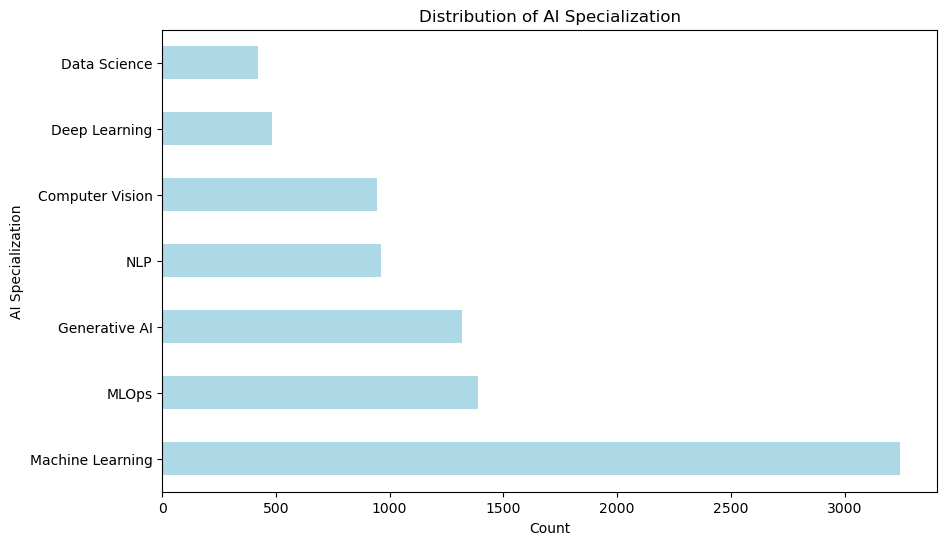

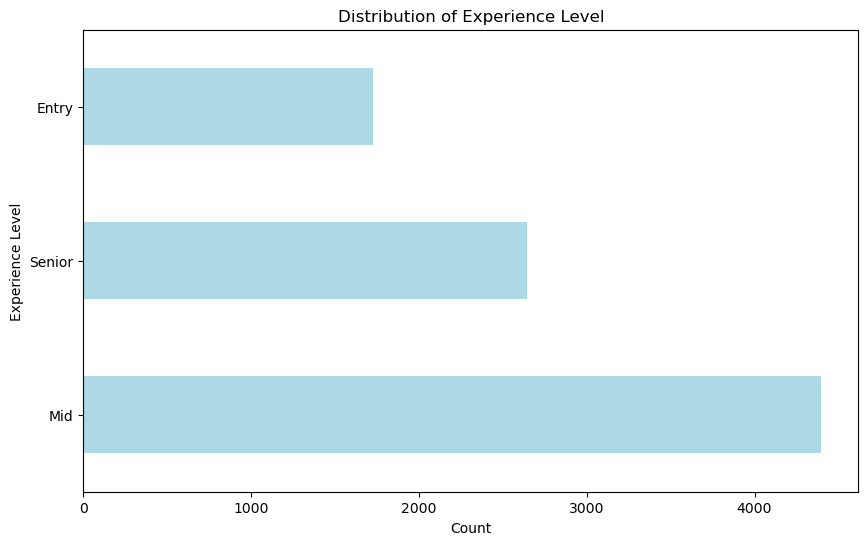

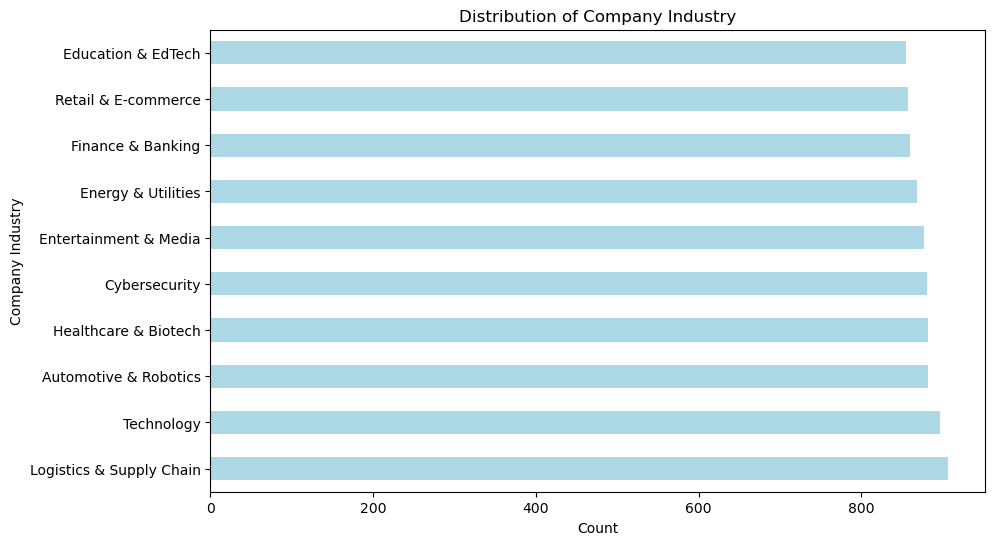

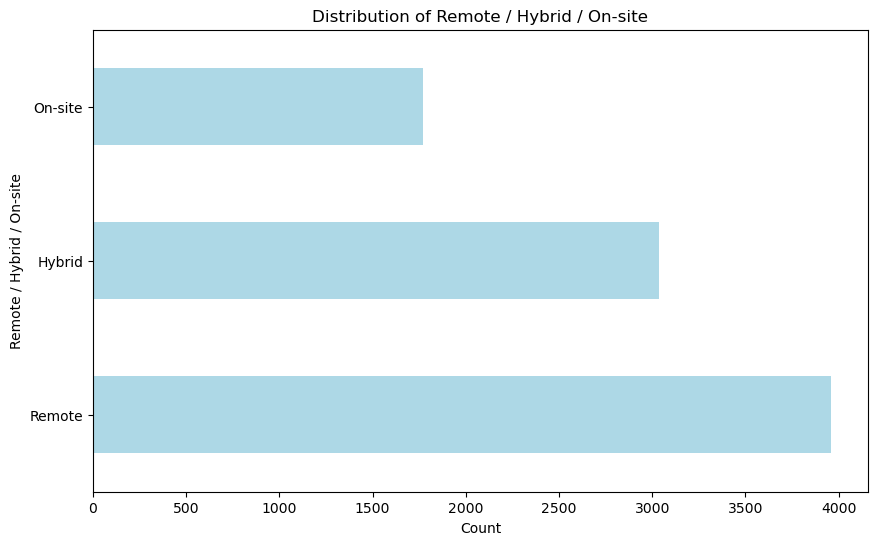

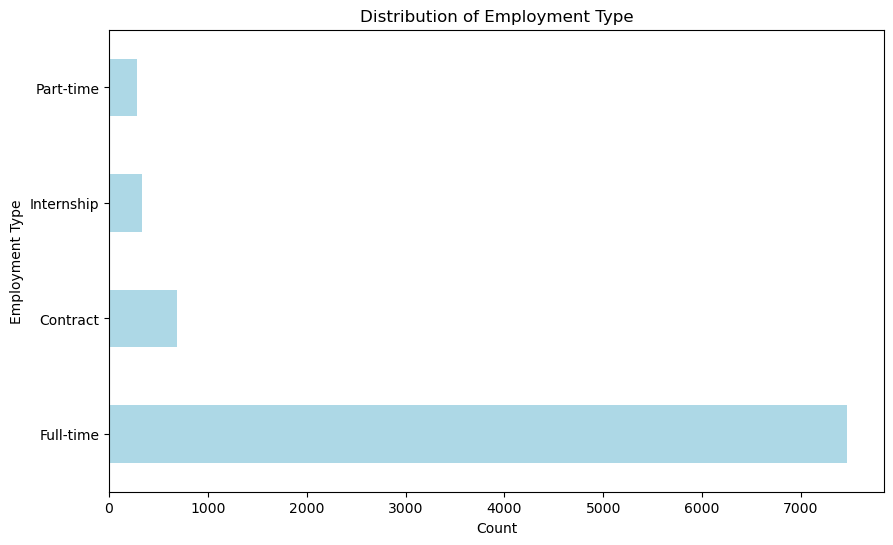

In [57]:
for col in seiw_columns:
    plt.figure(figsize=(10, 6))
    job_postings[col].value_counts().plot(kind='barh', color='lightblue')
    plt.title(f'Distribution of {col}')
    plt.xlabel('Count')
    plt.ylabel(col)
    plt.show()

In [60]:
# Let's show the value counts for AI Specialization, Experience Level, Company Industry, and Remote / Hybrid / On-site
print("AI Specialization Value Counts:\n", job_postings['AI Specialization'].value_counts())
print("\nExperience Level Value Counts:\n", job_postings['Experience Level'].value_counts())
print("\nCompany Industry Value Counts:\n", job_postings['Company Industry'].value_counts())
print("\nRemote / Hybrid / On-site Value Counts:\n", job_postings['Remote / Hybrid / On-site'].value_counts())
print("\nEmployment Type Value Counts:\n", job_postings['Employment Type'].value_counts())

AI Specialization Value Counts:
 AI Specialization
Machine Learning    3245
MLOps               1389
Generative AI       1318
NLP                  961
Computer Vision      945
Deep Learning        485
Data Science         423
Name: count, dtype: int64

Experience Level Value Counts:
 Experience Level
Mid       4399
Senior    2641
Entry     1726
Name: count, dtype: int64

Company Industry Value Counts:
 Company Industry
Logistics & Supply Chain    907
Technology                  897
Automotive & Robotics       882
Healthcare & Biotech        882
Cybersecurity               881
Entertainment & Media       877
Energy & Utilities          868
Finance & Banking           860
Retail & E-commerce         857
Education & EdTech          855
Name: count, dtype: int64

Remote / Hybrid / On-site Value Counts:
 Remote / Hybrid / On-site
Remote     3959
Hybrid     3035
On-site    1772
Name: count, dtype: int64

Employment Type Value Counts:
 Employment Type
Full-time     7465
Contract       684
Int

- For Specializations
    - Machine Learning, MLOps, and Generative AI all have over 1000 postings, the former being by far the most popular specialization
    - Natural Language Processing and Computer Vision are closer to 1000 postings
    - Deep Learning & Data Science are under 500 postings but are still asked for
- For Experience Level
    - Mid level experience (Starting around 5-10 years of experience and ending at around 25-35 years) is by far the most popular
    - There's less entry level postings than senior postings
- For Industry
    - While Logistics & Supply Chain is the most popular company industry with the job postings, there's not much difference here. 
    - Industries seem to be spread somewhat evenly
- For Work Arrangements
    - Remote and Hybrid jobs are more popular than on-site, the former having over twice as many job postings as on-site.
- For Employment Type
    - Full-time Positions are by far the most popular
    - Contract positions seem to be the 2nd most popular, having twice as many positions over part-time work
    - Internships, traditionally entry-level positions, are not the least popular employment type

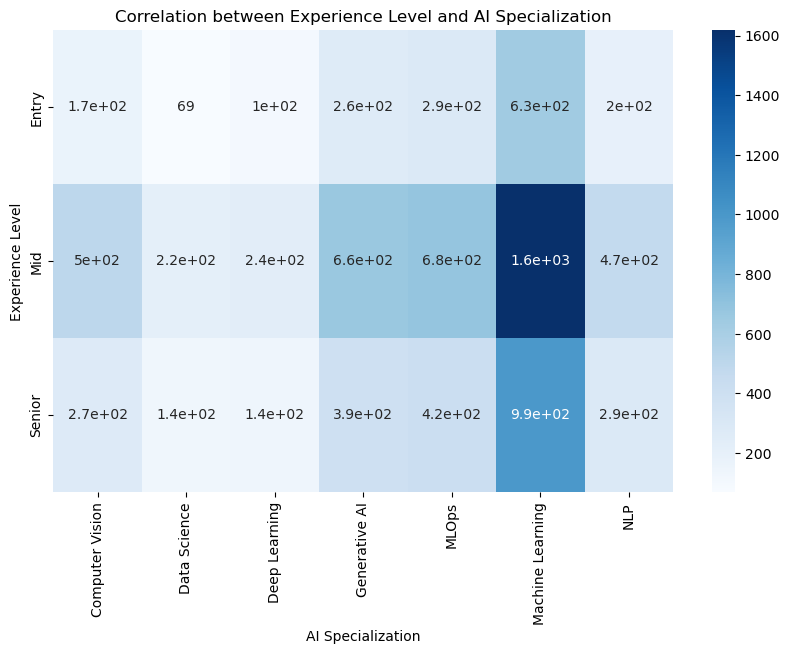

In [64]:
# Let's make a heat map between experience level and AI specialization to see if there are any correlations between the two variables.
experience_specialization_crosstab = pd.crosstab(job_postings['Experience Level'], job_postings['AI Specialization'])

plt.figure(figsize=(10, 6))
sns.heatmap(experience_specialization_crosstab, annot=True, cmap='Blues')
plt.title('Correlation between Experience Level and AI Specialization')
plt.xlabel('AI Specialization')
plt.ylabel('Experience Level')
plt.show()

- So Machine Learning, while having the most postings, requests more people with at least 5 years of experience, supposedly. 
- Overall, more roles ask for people who have medium experience level.
- The spread between Entry Level and Senior level positions across Specializations isn't that different, Machine Learning itself being more popular.

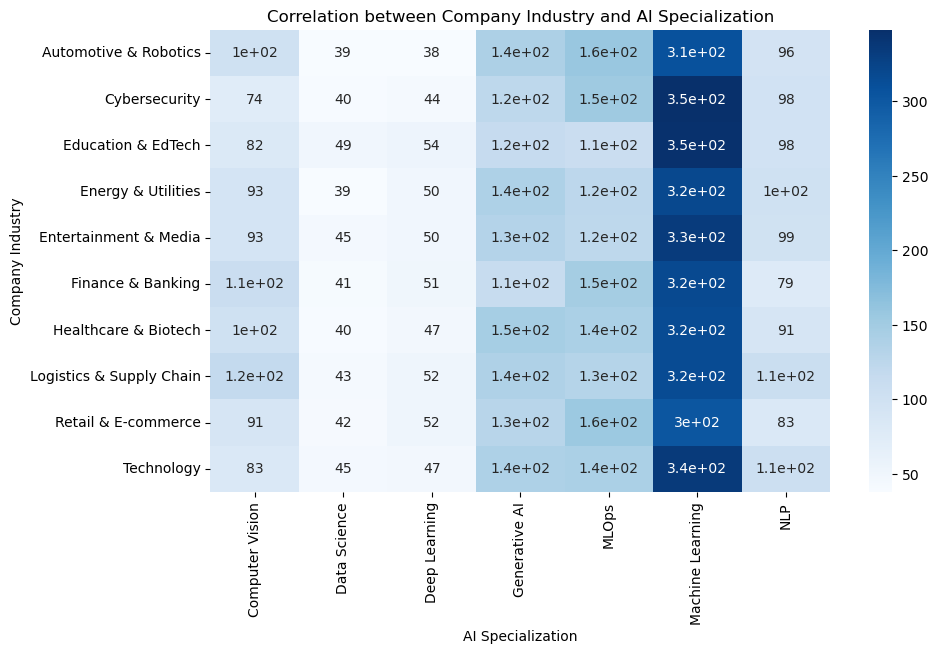

In [65]:
# Let's plot a heat map between Industries and AI Specialization to see if there are any correlations between the two variables.
industry_specialization_crosstab = pd.crosstab(job_postings['Company Industry'], job_postings['AI Specialization'])

plt.figure(figsize=(10, 6))
sns.heatmap(industry_specialization_crosstab, annot=True, cmap='Blues')
plt.title('Correlation between Company Industry and AI Specialization')
plt.xlabel('AI Specialization')
plt.ylabel('Company Industry')
plt.show()

I don't notice anything of note when analyzing specializations over industries. The spread seems to be equal across industries.

## Tackling Question 2 ##

How does compensation differ across AI specializations, experience levels, and work arrangements?

Some hypotheses I have going into this:
- More experienced AI roles have higher salaries.
- Compensation varies significantly between AI specializations.
- Work arrangement is associated with differences in compensation.

In [71]:
# Let's see the salary distribution again 
salaries = job_postings['Salary Range'].dropna()
salaries

0       $140,000 - $180,000
1       $140,000 - $180,000
2       $140,000 - $180,000
3       $140,000 - $180,000
4       $140,000 - $180,000
               ...         
8761      $191000 - $263000
8762      $125000 - $162000
8763    $139,704 - $166,248
8764    $198,379 - $230,511
8765      $138000 - $163000
Name: Salary Range, Length: 8766, dtype: object

In [ ]:
# Let's separate the salary range into minimum and maximum salary columns for better analysis.
job_postings[['Min Salary', 'Max Salary']] = job_postings['Salary Range'].str.split('-', expand=True)
# For each first character of both min and max salary, we will remove the dollar sign
job_postings['Min Salary'] = job_postings['Min Salary'].str.replace('$', '')
job_postings['Max Salary'] = job_postings['Max Salary'].str.replace('$', '')
# In both salary lists, we will remove any commas and convert the values to float
job_postings['Min Salary'] = job_postings['Min Salary'].str.replace(',', '').astype(float)
job_postings['Max Salary'] = job_postings['Max Salary'].str.replace(',', '').astype(float)
job_postings[['Min Salary', 'Max Salary']].head(3)

,Min Salary,Max Salary
0,140000.0,180000.0
1,140000.0,180000.0
2,140000.0,180000.0


In [97]:
# We can also add a 'Median Salary' column to the dataset by taking the average of the minimum and maximum salary for each job posting.
job_postings['Median Salary'] = (job_postings['Min Salary'] + job_postings['Max Salary']) / 2

In [ ]:
# Let's see the lowest and highest salaries in the dataset
min_low_salary = job_postings['Min Salary'].min()
min_high_salary = job_postings['Min Salary'].max()
max_low_salary = job_postings['Max Salary'].min()
max_high_salary = job_postings['Max Salary'].max()
print(f"The lowest salary offered in the dataset is: ${min_low_salary} - ${max_low_salary}")
print(f"The highest salary offered in the dataset is: ${min_high_salary} - ${max_high_salary}")

The lowest salary offered in the dataset is: $80000.0 - $90000.0
The highest salary offered in the dataset is: $231908.0 - $305000.0


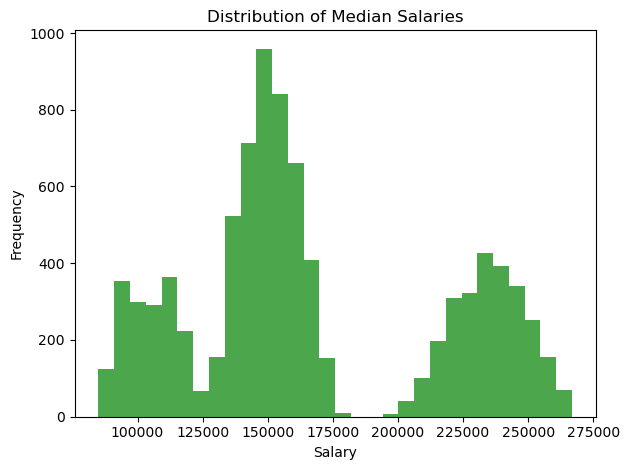

In [102]:
# We can also visualize the distribution of minimum and maximum salaries using histograms
# plt.figure(figsize=(12, 6))
# plt.subplot(1, 3, 1)
# plt.hist(job_postings['Min Salary'], bins=30, color='blue', alpha=0.7)
# plt.title('Distribution of Minimum Salaries')
# plt.xlabel('Salary')
# plt.ylabel('Frequency')

# plt.subplot(1, 3, 2)
# plt.hist(job_postings['Max Salary'], bins=30, color='red', alpha=0.7)
# plt.title('Distribution of Maximum Salaries')
# plt.xlabel('Salary')
# plt.ylabel('Frequency')

# plt.subplot(1, 3, 3)
plt.hist(job_postings['Median Salary'], bins=30, color='green', alpha=0.7) 
plt.title('Distribution of Median Salaries')
plt.xlabel('Salary')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

The median salary distribution shows that most job postings offer salaries in the range of $100,000 to $150,000. There are also some outliers with very high salaries, which may be due to executive-level positions or specialized roles in AI.

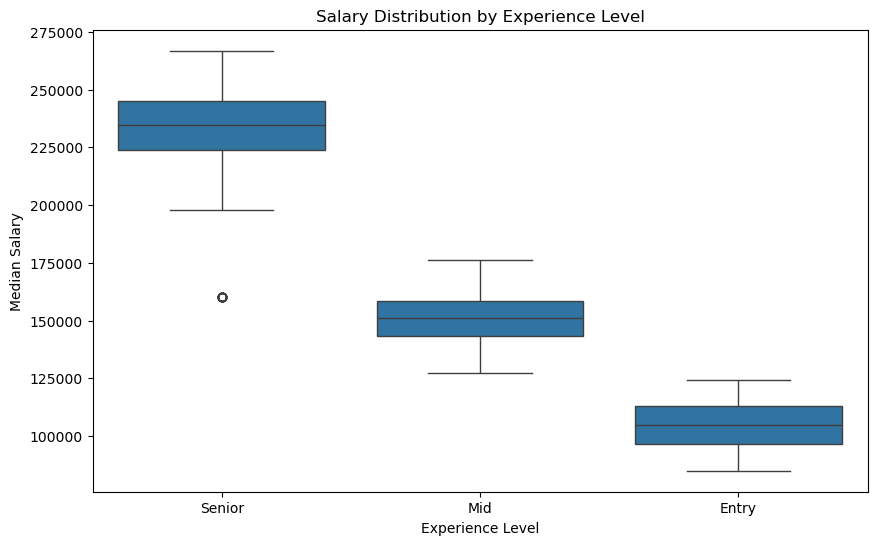

In [103]:
# Let's tackle salary x experience level. We can use a box plot to visualize the distribution of salaries across different experience levels.
plt.figure(figsize=(10, 6))
sns.boxplot(x='Experience Level', y='Median Salary', data=job_postings)
plt.title('Salary Distribution by Experience Level')
plt.xlabel('Experience Level')
plt.ylabel('Median Salary')
plt.show()

## Tackling Question 3 ##

To what extent do job titles correspond to the underlying characteristics of AI jobs?

In [23]:
job_posting_titles = job_postings['Job Title'].unique()
job_posting_titles.sort()
job_posting_titles

array(['AI / ML Engineer', 'AI Agent & Automation Developer',
       'AI Agentic Engineer - Multiple USA locations', 'AI Engineer',
       'AI Engineer II', 'AI Ethics Consultant',
       'AI Platform Engineer - Autonomous Agents', 'AI Product Manager',
       'AI Research Scientist', 'AI Solution Architect',
       'AI Solutions Architect', 'AI Systems Engineer', 'AI/ML Engineer',
       'AI/ML Engineer, Deployed',
       'Applied AI Engineer, Global Public Sector',
       'Artificial (AI) Engineer', 'Artificial Intelligence Engineer',
       'Computer Vision Engineer', 'Computer Vision Researcher',
       'Data Engineer', 'Data Scientist', 'Deep Learning Specialist',
       'Gen AI Engineer', 'Generative AI Architect',
       'LLM Software Developer', 'ML Infrastructure Engineer',
       'ML Platform Developer', 'MLOps Engineer',
       'Machine Learning  Engineer', 'Machine Learning Engineer',
       'Machine Learning Engineer, Global Public Sector', 'NLP Engineer',
       'NLP Rese

Text(0.5, 1.0, 'Top 10 Job Titles')

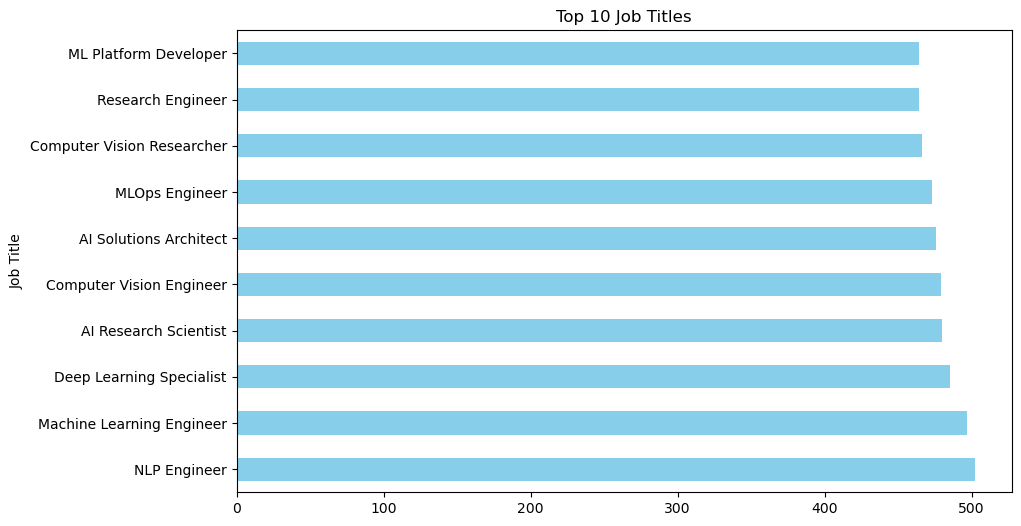

In [11]:
job_postings['Job Title'].value_counts().head(10).plot(kind='barh', figsize=(10, 6), color='skyblue')
plt.title('Top 10 Job Titles')

array(['AI / ML Engineer', 'AI Agent & Automation Developer',
       'AI Agentic Engineer - Multiple USA locations', 'AI Engineer',
       'AI Engineer II', 'AI Ethics Consultant',
       'AI Platform Engineer - Autonomous Agents', 'AI Product Manager',
       'AI Research Scientist', 'AI Solution Architect',
       'AI Solutions Architect', 'AI Systems Engineer', 'AI/ML Engineer',
       'AI/ML Engineer, Deployed',
       'Applied AI Engineer, Global Public Sector',
       'Artificial (AI) Engineer', 'Artificial Intelligence Engineer',
       'Computer Vision Engineer', 'Computer Vision Researcher',
       'Data Engineer', 'Data Scientist', 'Deep Learning Specialist',
       'Gen AI Engineer', 'Generative AI Architect',
       'LLM Software Developer', 'ML Infrastructure Engineer',
       'ML Platform Developer', 'MLOps Engineer',
       'Machine Learning  Engineer', 'Machine Learning Engineer',
       'Machine Learning Engineer, Global Public Sector', 'NLP Engineer',
       'NLP Rese

This is a lot of titles. We'll start by showing the ones with multiple job postings

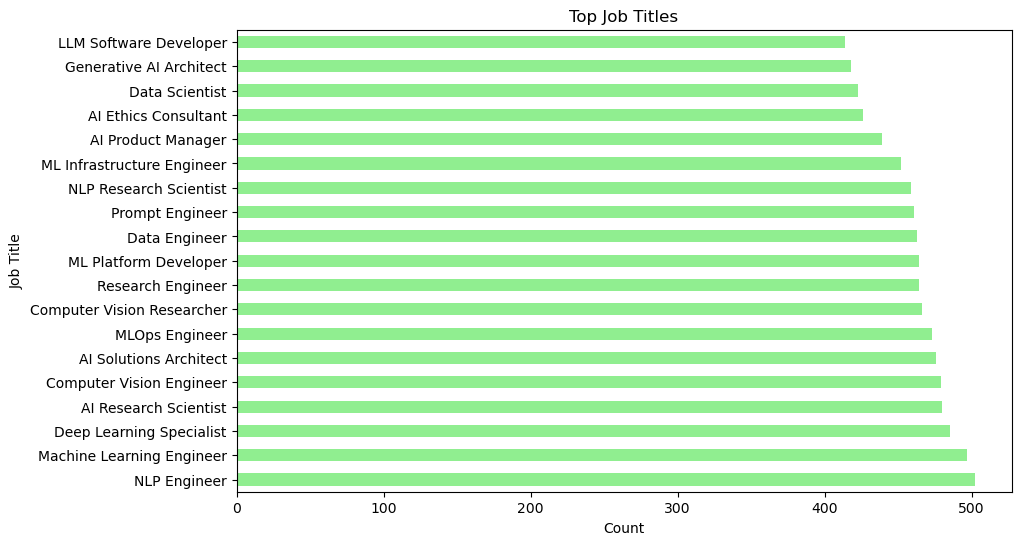

In [20]:
# Plotting the job posting counts by title that have more than 100 postings and then putting those values into a horizontal bar chart, then putting the job posting titles in their own list
job_postings['Job Title'].value_counts()[job_postings['Job Title'].value_counts() > 100].plot(kind='barh', figsize=(10, 6), color='lightgreen')
plt.title('Top Job Titles')
plt.xlabel('Count')
plt.ylabel('Job Title')
plt.show()
popular_job_titles = job_postings['Job Title'].value_counts()[job_postings['Job Title'].value_counts() > 100].index.tolist()

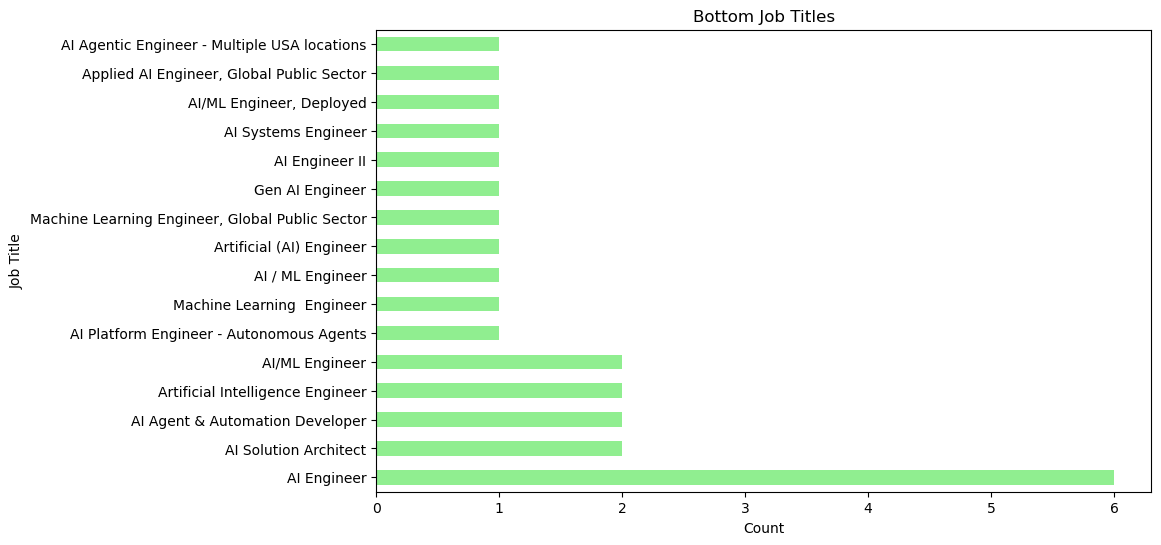

In [21]:
# Plotting the job posting counts by title that have less than 100 postings, and putting those values into a horizontal bar chart, then putting the job posting titles in their own list
job_postings['Job Title'].value_counts()[job_postings['Job Title'].value_counts() < 100].plot(kind='barh', figsize=(10, 6), color='lightgreen')
plt.title('Bottom Job Titles')
plt.xlabel('Count')
plt.ylabel('Job Title')
plt.show()
less_popular_job_titles = job_postings['Job Title'].value_counts()[job_postings['Job Title'].value_counts() < 100].index.tolist()

In [22]:
print("Popular Job Titles:", popular_job_titles)
print("Less Popular Job Titles:", less_popular_job_titles)

Popular Job Titles: ['NLP Engineer', 'Machine Learning Engineer', 'Deep Learning Specialist', 'AI Research Scientist', 'Computer Vision Engineer', 'AI Solutions Architect', 'MLOps Engineer', 'Computer Vision Researcher', 'Research Engineer', 'ML Platform Developer', 'Data Engineer', 'Prompt Engineer', 'NLP Research Scientist', 'ML Infrastructure Engineer', 'AI Product Manager', 'AI Ethics Consultant', 'Data Scientist', 'Generative AI Architect', 'LLM Software Developer']
Less Popular Job Titles: ['AI Engineer', 'AI Solution Architect', 'AI Agent & Automation Developer', 'Artificial Intelligence Engineer', 'AI/ML Engineer', 'AI Platform Engineer - Autonomous Agents', 'Machine Learning  Engineer', 'AI / ML Engineer', 'Artificial (AI) Engineer', 'Machine Learning Engineer, Global Public Sector', 'Gen AI Engineer', 'AI Engineer II', 'AI Systems Engineer', 'AI/ML Engineer, Deployed', 'Applied AI Engineer, Global Public Sector', 'AI Agentic Engineer - Multiple USA locations']


So we can see which job titles have more postings than others. I chose 100 as a starting point to see what would happen, but there's a drastic range differeence in the amount of postings for these titles.
However, specific titles don't mean unpopular or unwanted.